# F1 Race Analysis

Working notebook — grows alongside the analysis modules.
Each section validates a block against real race data.

**Race used:** 2023 Bahrain GP — clean race, no major weather events, strong teammate battles (VER/PER, HAM/RUS).

Sections:
1. Load & inspect raw lap data
2. Lap time volatility (Block 2)
3. Pairs / cointegration (Block 3)

In [7]:
import sys
sys.path.insert(0, '..')  # so imports find data/ and analysis/ from the repo root

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from data.fastf1_loader import get_accurate_laps, get_teammate_laps

## 1. Load race data

First run will download from the FastF1 API and cache locally — takes ~30s.  
Every run after that is instant from cache.

`get_accurate_laps` returns only `IsAccurate=True` laps — pit in/out laps and SC laps are already stripped.

In [8]:
YEAR = 2023
EVENT = 'Bahrain'

laps = get_accurate_laps(YEAR, EVENT)

print(f"Total clean laps loaded: {len(laps)}")
print(f"Drivers: {sorted(laps['Driver'].unique())}")
laps.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


Total clean laps loaded: 914
Drivers: ['ALB', 'ALO', 'BOT', 'DEV', 'GAS', 'HAM', 'HUL', 'LEC', 'MAG', 'NOR', 'OCO', 'PER', 'PIA', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'ZHO']


,Driver,Team,LapNumber,LapTime,Stint,Compound,TyreLife,Position,IsAccurate,LapTime_s
0,VER,Red Bull Racing,2.0,0 days 00:01:37.974000,1.0,SOFT,5.0,1.0,True,97.974
1,VER,Red Bull Racing,3.0,0 days 00:01:38.006000,1.0,SOFT,6.0,1.0,True,98.006
2,VER,Red Bull Racing,4.0,0 days 00:01:37.976000,1.0,SOFT,7.0,1.0,True,97.976
3,VER,Red Bull Racing,5.0,0 days 00:01:38.035000,1.0,SOFT,8.0,1.0,True,98.035
4,VER,Red Bull Racing,6.0,0 days 00:01:37.986000,1.0,SOFT,9.0,1.0,True,97.986


## Lap times across the race — all drivers

Plotting every driver's lap times by lap number.  
What to look for:
- **Stint structure** — clusters of faster laps followed by a gap (pit stop) then faster laps again on fresh tyres
- **Outliers** — any anomalously slow laps that slipped through the `IsAccurate` filter
- **Backmarkers** — should sit visibly above the frontrunners

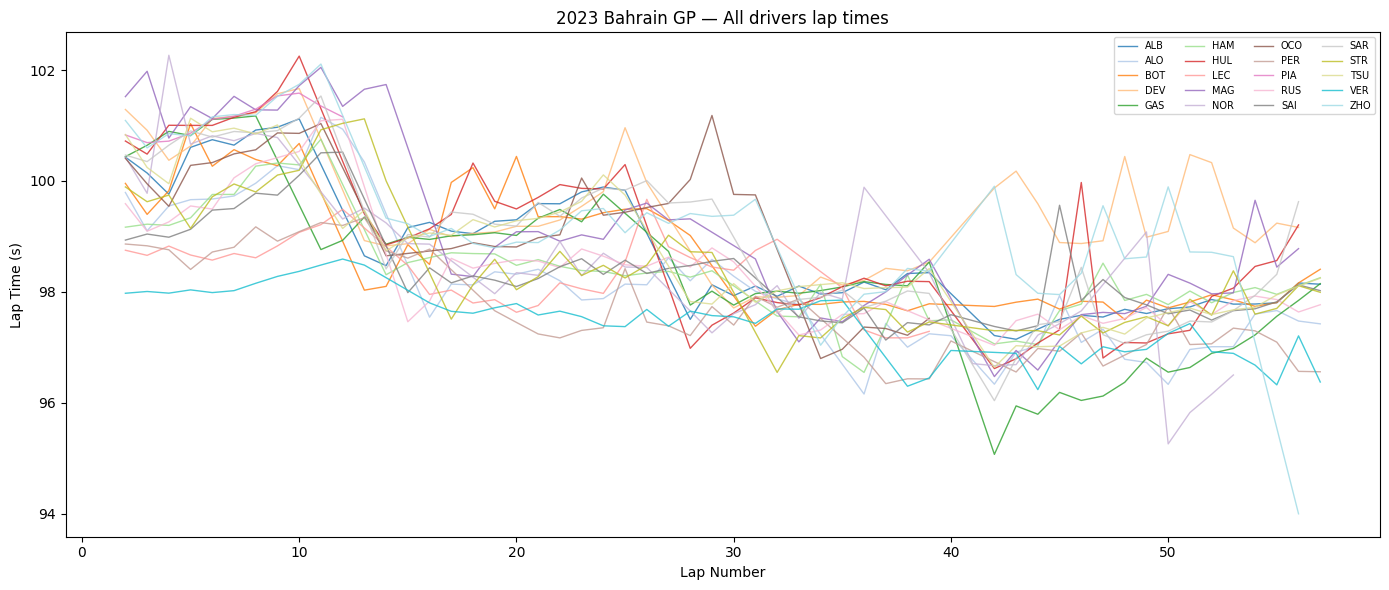

In [9]:
drivers = sorted(laps['Driver'].unique())
colors = cm.tab20(np.linspace(0, 1, len(drivers)))

fig, ax = plt.subplots(figsize=(14, 6))

for driver, color in zip(drivers, colors):
    d = laps[laps['Driver'] == driver]
    ax.plot(d['LapNumber'], d['LapTime_s'], label=driver, color=color, linewidth=1, alpha=0.8)

ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (s)')
ax.set_title('2023 Bahrain GP — All drivers lap times')
ax.legend(ncol=4, fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()